In [1]:
# HW1 – CS6220 Fall 2025
# Problem 1.x – K-means Clustering Experiments
# Author: Mathis Doutre (mdoutre3@gatech.edu)
# --------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, MiniBatchKMeans

sns.set(style="whitegrid", font_scale=1.2)


In [17]:
datasets = {
    "tiny (5k, 4D)": make_blobs(n_samples=5000, centers=5, n_features=4, random_state=42)[0],
    "small (50k, 4D)": make_blobs(n_samples=50000, centers=5, n_features=4, random_state=42)[0],
    "medium (500k, 4D)": make_blobs(n_samples=500000, centers=5, n_features=4, random_state=42)[0],
    "large (2M, 4D)": make_blobs(n_samples=2000000, centers=5, n_features=4, random_state=42)[0],
    "medium, high dimentionality (500k, 10D)": make_blobs(n_samples=500000, centers=5, n_features=10, random_state=42)[0],
}

for name, X in datasets.items():
    print(f"{name}: shape={X.shape}")


tiny (5k, 4D): shape=(5000, 4)
small (50k, 4D): shape=(50000, 4)
medium (500k, 4D): shape=(500000, 4)
large (2M, 4D): shape=(2000000, 4)
medium, high dimentionality (500k, 10D): shape=(500000, 10)


In [30]:
def run_kmeans(X, k=3, init="k-means++", impl="kmeans"):
    start = time.time()
    if impl == "kmeans":
        model = KMeans(n_clusters=k, init=init, n_init=10, random_state=42)
    elif impl == "minibatch":
        model = MiniBatchKMeans(n_clusters=k, init=init, n_init=10, batch_size=2048, random_state=42)
    else:
        raise ValueError("Unknown impl")
    model.fit(X)
    runtime = time.time() - start
    return {
        "impl": impl,
        "k": k,
        "init": init,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "runtime": runtime,
        "inertia": model.inertia_,
    }


In [31]:
results = []

# Parameters to test
k_values = [3, 5, 7]
inits = ["k-means++", "random", "custom"]
impls = ["kmeans", "minibatch"]

def custom_init(X, k):
    # Pick first k samples as starting centroids (naive but valid)
    return X[:k]

for ds_name, X in datasets.items():
    for impl in impls:
        for k in k_values:
            for init in inits:
                if init == "custom":
                    init_val = custom_init(X, k)
                else:
                    init_val = init
                res = run_kmeans(X, k=k, init=init_val, impl=impl)
                res["dataset"] = ds_name
                if isinstance(init, str):
                  res["init"] = init
                else:
                  res["init"] = "custom"

                results.append(res)

df = pd.DataFrame(results)
df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1920: RuntimeWarning: Explicit initial center position passed: performing only one init in MiniBatchKMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=3)
/usr/local/lib/python3.1

,impl,k,init,n_samples,n_features,runtime,inertia,dataset
0,kmeans,3,k-means++,5000,4,0.025392,197701.586807,"tiny (5k, 4D)"
1,kmeans,3,random,5000,4,0.015463,197701.586807,"tiny (5k, 4D)"
2,kmeans,3,custom,5000,4,0.004015,197701.586807,"tiny (5k, 4D)"
3,kmeans,5,k-means++,5000,4,0.028502,20071.874993,"tiny (5k, 4D)"
4,kmeans,5,random,5000,4,0.018508,20071.874993,"tiny (5k, 4D)"


In [32]:
df.to_csv("kmeans_results.csv", index=False)
df



,impl,k,init,n_samples,n_features,runtime,inertia,dataset
0,kmeans,3,k-means++,5000,4,0.025392,1.977016e+05,"tiny (5k, 4D)"
1,kmeans,3,random,5000,4,0.015463,1.977016e+05,"tiny (5k, 4D)"
2,kmeans,3,custom,5000,4,0.004015,1.977016e+05,"tiny (5k, 4D)"
3,kmeans,5,k-means++,5000,4,0.028502,2.007187e+04,"tiny (5k, 4D)"
4,kmeans,5,random,5000,4,0.018508,2.007187e+04,"tiny (5k, 4D)"
...,...,...,...,...,...,...,...,...
85,minibatch,5,random,500000,10,0.056548,1.825155e+07,"medium, high dimentionality (500k, 10D)"
86,minibatch,5,custom,500000,10,0.305886,1.830734e+07,"medium, high dimentionality (500k, 10D)"
87,minibatch,7,k-means++,500000,10,0.108231,4.874849e+06,"medium, high dimentionality (500k, 10D)"
88,minibatch,7,random,500000,10,0.062478,4.898952e+06,"medium, high dimentionality (500k, 10D)"


/tmp/ipython-input-905250245.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


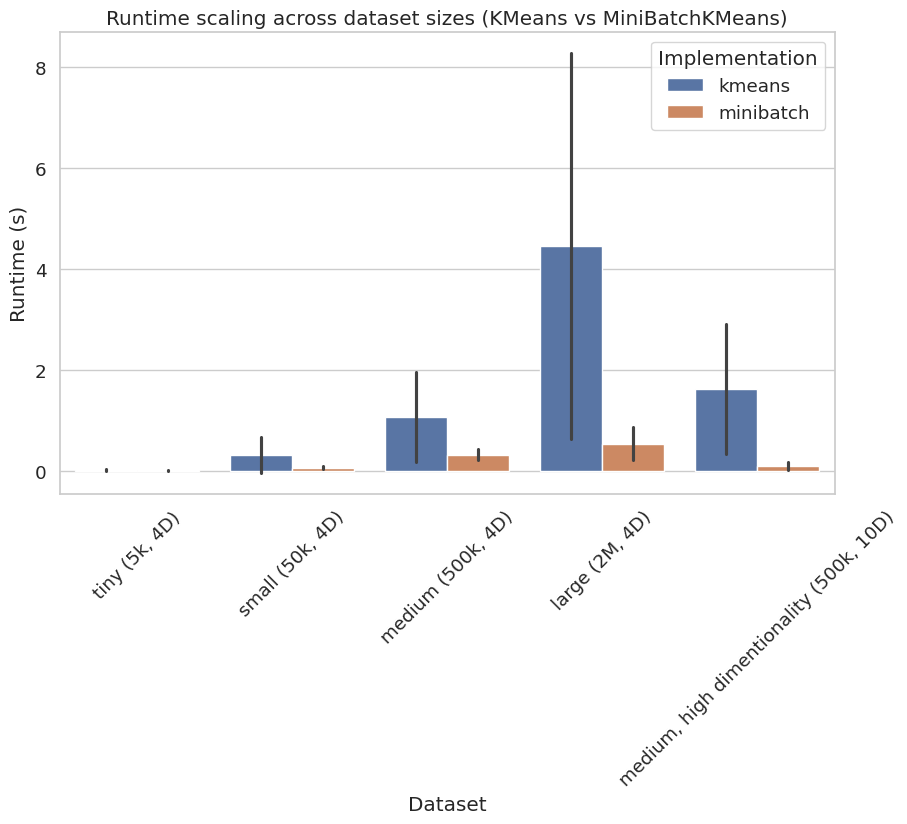

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x="dataset", y="runtime", hue="impl",
    ci="sd",
)
plt.title("Runtime scaling across dataset sizes (KMeans vs MiniBatchKMeans)")
plt.ylabel("Runtime (s)")
plt.xlabel("Dataset")
plt.legend(title="Implementation")

# Rotate x-axis labels
plt.xticks(rotation=45)   # e.g. 45°, you can try 30, 60, or 90
plt.show()


/tmp/ipython-input-2914648987.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.catplot(


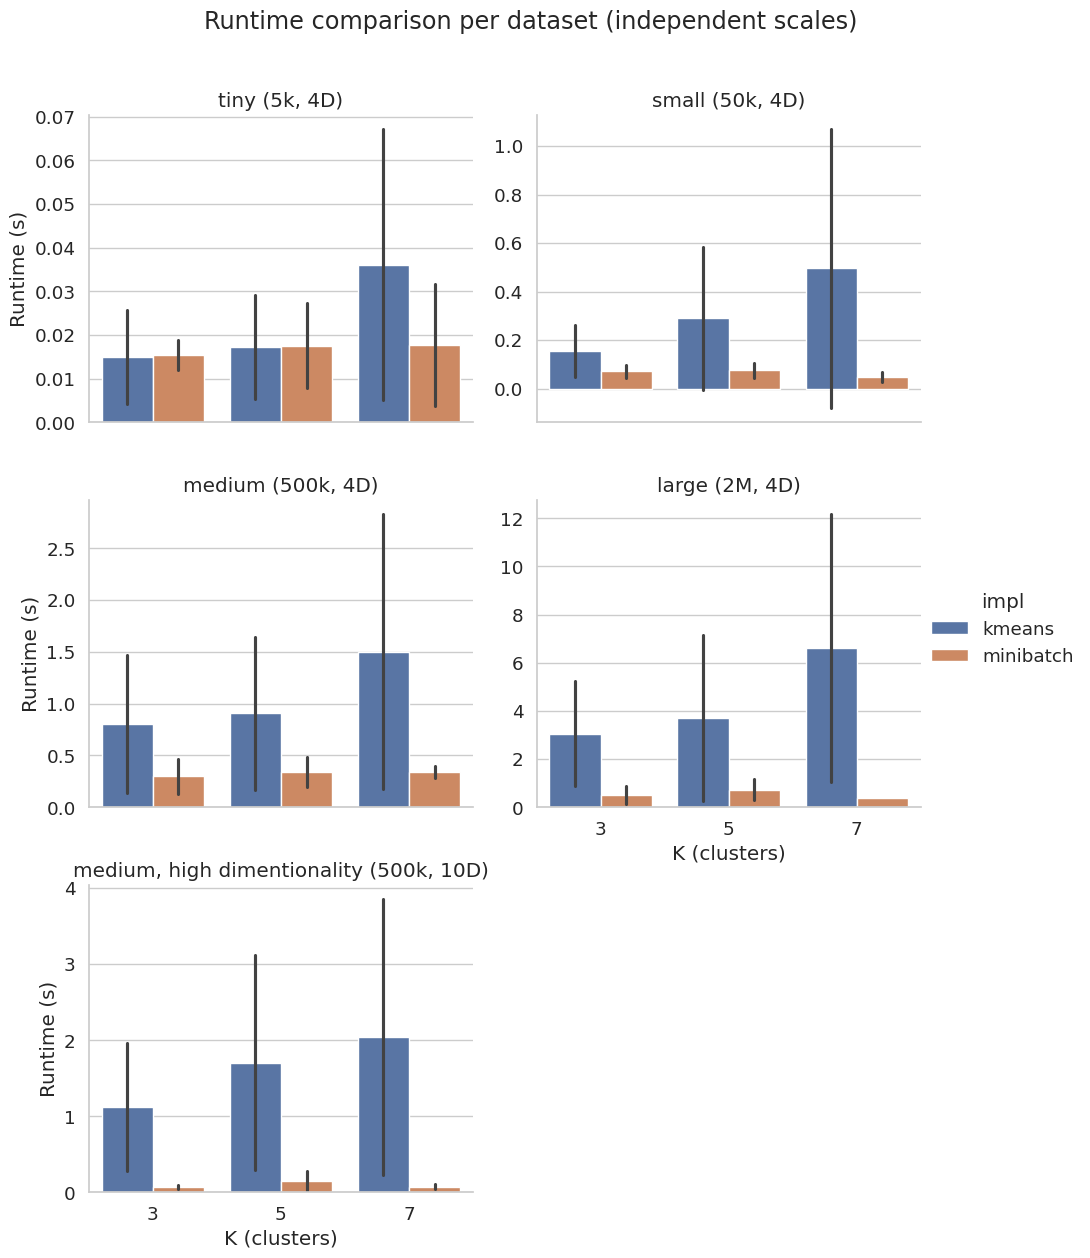

In [34]:
g = sns.catplot(
    data=df, x="k", y="runtime", hue="impl",
    col="dataset", kind="bar", ci="sd", col_wrap=2,
    height=4, aspect=1.2, sharey=False
)
g.set_titles("{col_name}")
g.set_axis_labels("K (clusters)", "Runtime (s)")
plt.suptitle("Runtime comparison per dataset (independent scales)", y=1.05)
plt.show()


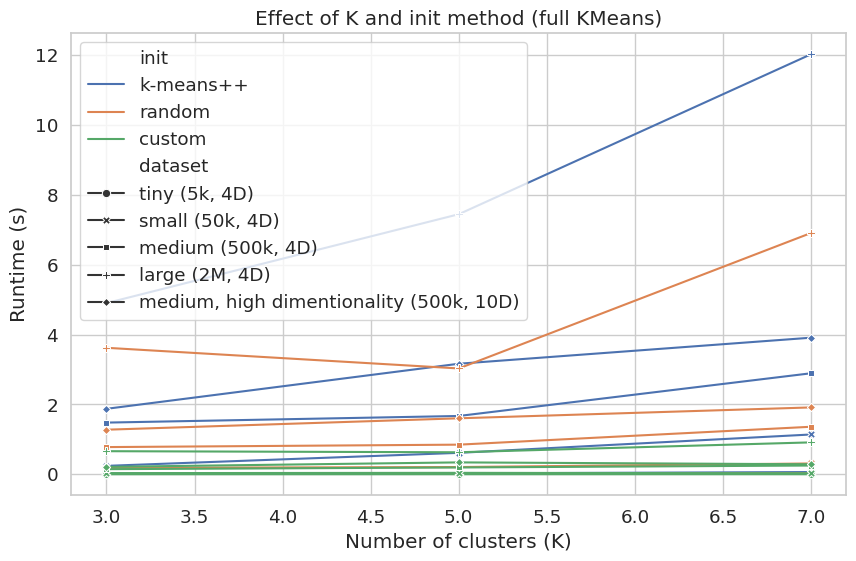

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df[df["impl"]=="kmeans"],
    x="k", y="runtime", hue="init", style="dataset", markers=True, dashes=False
)
plt.title("Effect of K and init method (full KMeans)")
plt.ylabel("Runtime (s)")
plt.xlabel("Number of clusters (K)")
plt.show()


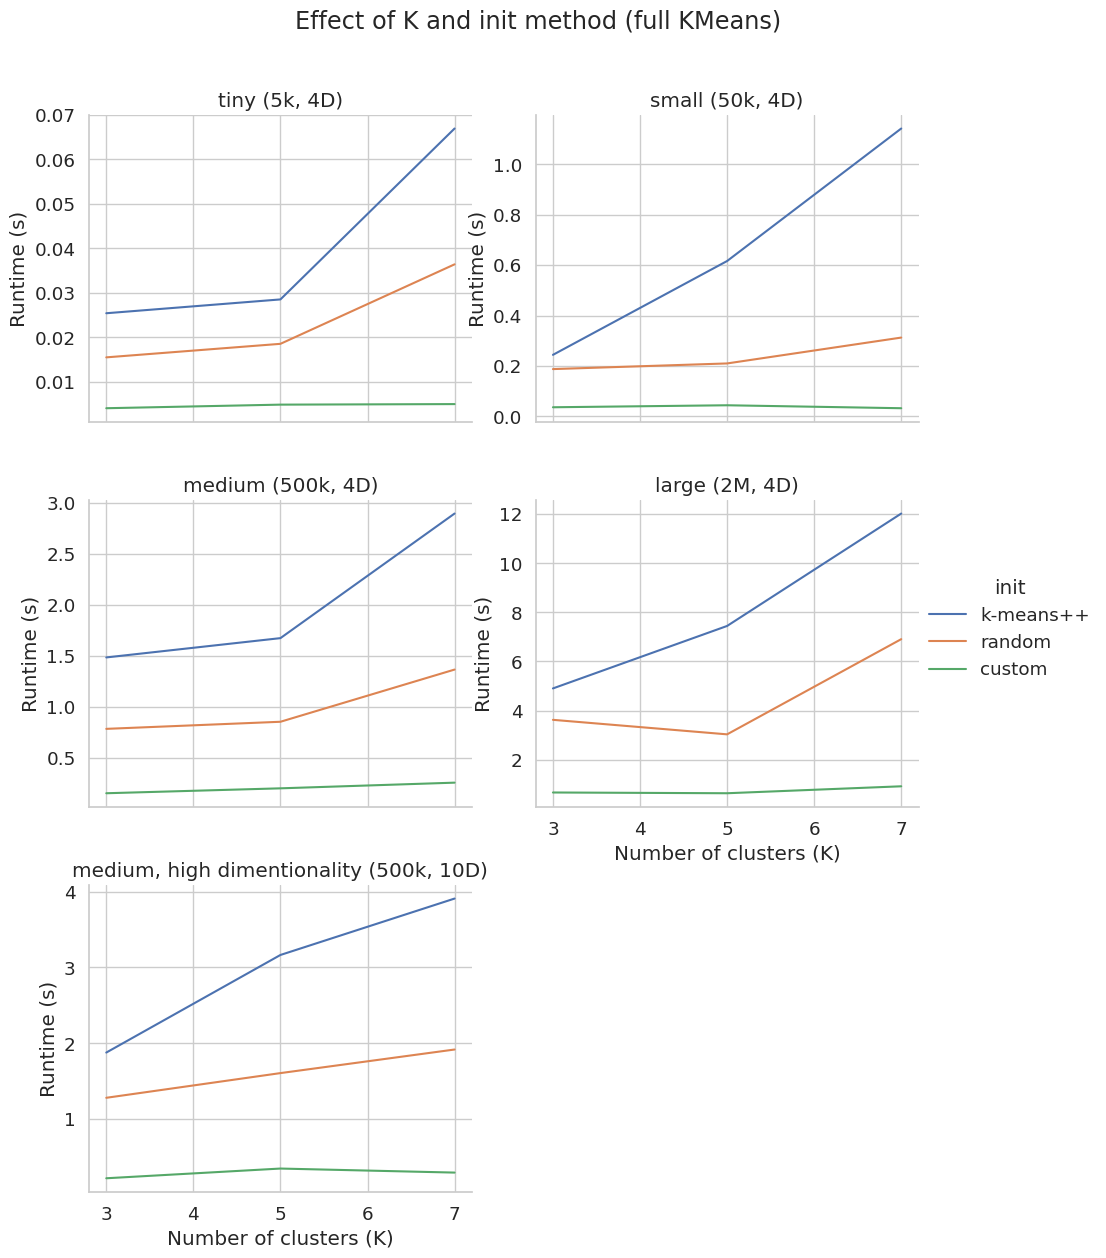

In [36]:
g = sns.relplot(
    data=df[df["impl"]=="kmeans"],
    x="k", y="runtime", hue="init", kind="line",
    col="dataset", col_wrap=2, markers=True, dashes=False,
    height=4, aspect=1.2, facet_kws={'sharey': False, 'sharex': True}
)

# Force labels on every axis, not just the outer ones
for ax in g.axes.flat:
    ax.set_xlabel("Number of clusters (K)")
    ax.set_ylabel("Runtime (s)")

g.set_titles("{col_name}")
plt.suptitle("Effect of K and init method (full KMeans)", y=1.05)
plt.show()


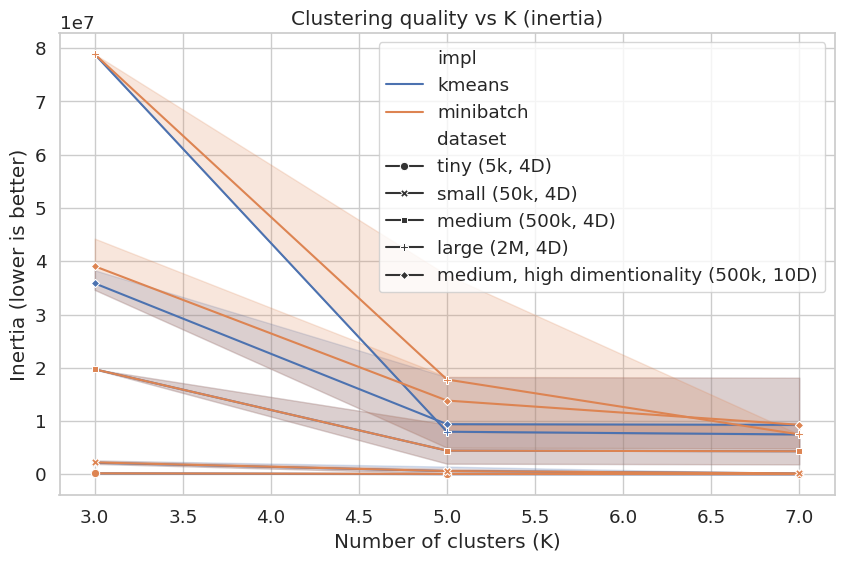

In [25]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="k", y="inertia", hue="impl", style="dataset", markers=True, dashes=False
)
plt.title("Clustering quality vs K (inertia)")
plt.ylabel("Inertia (lower is better)")
plt.xlabel("Number of clusters (K)")
plt.show()


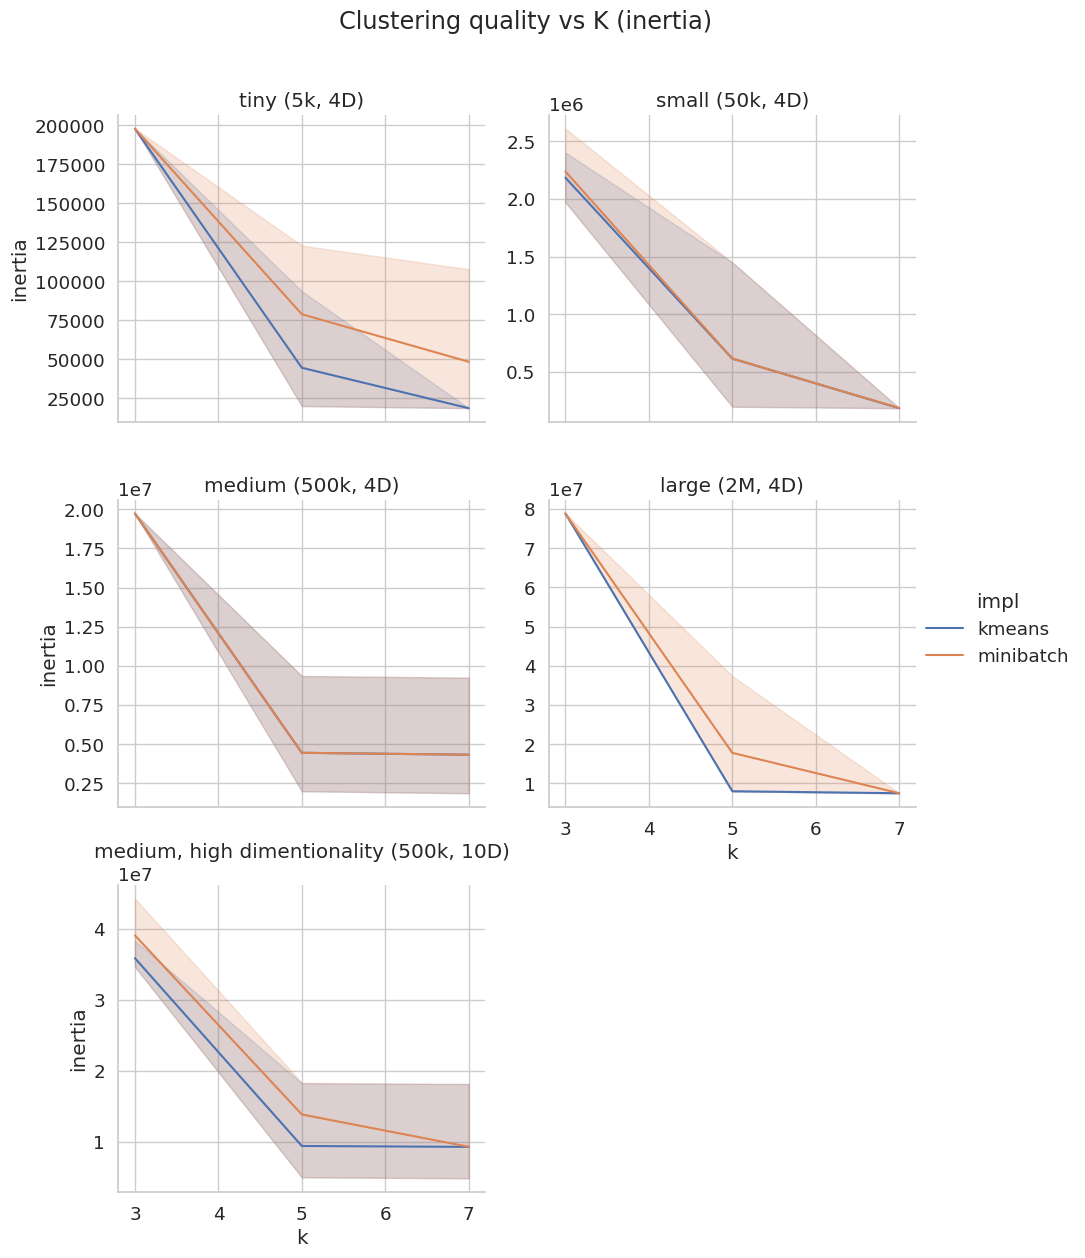

In [37]:
g = sns.relplot(
    data=df,
    x="k", y="inertia", hue="impl", kind="line",
    col="dataset", col_wrap=2, markers=True, dashes=False,
    height=4, aspect=1.2, facet_kws={'sharey': False, 'sharex': True}
)


g.set_titles("{col_name}")
plt.suptitle("Clustering quality vs K (inertia)", y=1.05)
plt.show()


In [38]:
print("=== Average runtime by dataset & implementation ===")
print(df.groupby(["dataset","impl"])["runtime"].mean())

print("\n=== Effect of init method ===")
print(df.groupby(["dataset","init"])["runtime"].mean())

print("\n=== Scaling effect (runtime per sample) ===")
df["time_per_sample"] = df["runtime"] / df["n_samples"]
print(df.groupby("dataset")["time_per_sample"].mean())

=== Average runtime by dataset & implementation ===
dataset                                  impl     
large (2M, 4D)                           kmeans       4.458770
                                         minibatch    0.539163
medium (500k, 4D)                        kmeans       1.071075
                                         minibatch    0.325513
medium, high dimentionality (500k, 10D)  kmeans       1.621913
                                         minibatch    0.095704
small (50k, 4D)                          kmeans       0.313891
                                         minibatch    0.064473
tiny (5k, 4D)                            kmeans       0.022779
                                         minibatch    0.016917
Name: runtime, dtype: float64

=== Effect of init method ===
dataset                                  init     
large (2M, 4D)                           custom       0.766731
                                         k-means++    4.293254
                             

In [39]:
# === Final summarized results for report ===

summary = (
    df.groupby(["dataset", "impl", "k", "init"])
      .agg(runtime_mean=("runtime", "mean"),
           runtime_std=("runtime", "std"),
           inertia_mean=("inertia", "mean"))
      .reset_index()
)

# Round for readability
summary = summary.round(3)

# Display nicely
import IPython.display as disp
disp.display(summary)

# Save to CSV for deliverables
summary.to_csv("kmeans_summary_results.csv", index=False)


,dataset,impl,k,init,runtime_mean,runtime_std,inertia_mean
0,"large (2M, 4D)",kmeans,3,custom,0.664,NaN,7.886281e+07
1,"large (2M, 4D)",kmeans,3,k-means++,4.900,NaN,7.886281e+07
2,"large (2M, 4D)",kmeans,3,random,3.621,NaN,7.886281e+07
3,"large (2M, 4D)",kmeans,5,custom,0.633,NaN,8.000991e+06
4,"large (2M, 4D)",kmeans,5,k-means++,7.442,NaN,8.000991e+06
...,...,...,...,...,...,...,...
85,"tiny (5k, 4D)",minibatch,5,k-means++,0.028,NaN,2.007567e+04
86,"tiny (5k, 4D)",minibatch,5,random,0.017,NaN,1.228234e+05
87,"tiny (5k, 4D)",minibatch,7,custom,0.007,NaN,1.879978e+04
88,"tiny (5k, 4D)",minibatch,7,k-means++,0.034,NaN,1.877390e+04


In [40]:
# --- BONUS: print runtimes for each dataset / K / init ---
import time

for ds_name, X in datasets.items():
    print(f"\n=== Dataset: {ds_name} (n={len(X)}, d={X.shape[1]}) ===")
    for k in k_values:
        for init in inits:
            init_val = init if init != "custom" else X[:k]
            t0 = time.perf_counter()
            km = KMeans(n_clusters=k, init=init_val, n_init=10, max_iter=300, random_state=42)
            km.fit(X)
            runtime = time.perf_counter() - t0
            print(f" K={k:<2} init={init:<10} runtime={runtime:.3f} sec")



=== Dataset: tiny (5k, 4D) (n=5000, d=4) ===
 K=3  init=k-means++  runtime=0.031 sec
 K=3  init=random     runtime=0.021 sec
 K=3  init=custom     runtime=0.005 sec
 K=5  init=k-means++  runtime=0.039 sec
 K=5  init=random     runtime=0.033 sec
 K=5  init=custom     runtime=0.007 sec


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


 K=7  init=k-means++  runtime=0.086 sec
 K=7  init=random     runtime=0.060 sec
 K=7  init=custom     runtime=0.008 sec

=== Dataset: small (50k, 4D) (n=50000, d=4) ===


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


 K=3  init=k-means++  runtime=0.525 sec
 K=3  init=random     runtime=0.203 sec


...

 K=3  init=custom     runtime=0.224 sec
 K=5  init=k-means++  runtime=2.173 sec
 K=5  init=random     runtime=1.380 sec


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


 K=5  init=custom     runtime=0.364 sec
 K=7  init=k-means++  runtime=4.032 sec
 K=7  init=random     runtime=2.809 sec


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_kmeans.py:1404: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


 K=7  init=custom     runtime=0.477 sec
